In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install gensim konlpy kiwipiepy


In [ ]:
import pandas as pd
import numpy as np
import time
from tqdm.notebook import tqdm
import time, pickle, os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from konlpy.tag import Okt
from collections import Counter
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.doc2vec import TaggedDocument
from gensim.models import Doc2Vec
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.cluster import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD

import html


In [ ]:
import glob

pickle_file_path = glob.glob('/content/drive/MyDrive/Colab Notebooks/cluster*.pkl')

In [ ]:
df = pd.DataFrame()

for p in pickle_file_path :
    with open(p, 'rb') as f:
        new_df = pickle.load(f)
    df = pd.concat([df, new_df])

df = df.reset_index(drop =True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31011 entries, 0 to 31010
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              29119 non-null  object
 1   content           27083 non-null  object
 2   contents          2978 non-null   object
 3   text              950 non-null    object
 4   articles          31011 non-null  object
 5   article_words     31011 non-null  object
 6   re_article_words  31011 non-null  object
 7   cluster_v1        31011 non-null  int64 
 8   cluster_v2        31011 non-null  int64 
 9   action_cluster    31011 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 2.4+ MB


In [ ]:
'''
# ============================================
# 1. 라이브러리 설치
# ============================================
!pip install transformers torch --quiet

# ============================================
# 2. 모델 불러오기
# ============================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

# 한국어 감정분석 성능이 높은 모델
MODEL_NAME = "beomi/KcELECTRA-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

# ============================================
# 3. 감정 점수 계산 함수
# ============================================
def get_sentiment_score(text):
    """
    text: 문자열
    return: -1 ~ +1 사이의 감정 점수 (긍정 - 부정)
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0

    # BERT 입력 생성
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = model(**inputs).logits

    # softmax 확률
    probs = F.softmax(logits, dim=1)[0]

    # label 0 = negative, labeling에 따라 positive index 확인
    # KcELECTRA 기준: [Negative, Positive]
    score = float(probs[1] - probs[0])  # positive - negative
    return score


# ============================================
# 4. 데이터프레임 로드 (예시)
# ============================================
# df['articles'] 컬럼에 텍스트가 있다고 가정
# df = pd.read_csv("your_data.csv")
# 예시용
# df = pd.DataFrame({"articles": ["너무 힘들다", "오늘 기분 좋음", "그냥 그런 하루"]})

# ============================================
# 5. 감정 점수 계산
# ============================================
sentiment_scores = []
for text in tqdm(df["articles"], desc="감정 점수 계산 중"):
    sentiment_scores.append(get_sentiment_score(text))

df["sentiment_score"] = sentiment_scores

# ============================================
# 6. 결과 저장
# ============================================
df.to_csv("/content/drive/MyDrive/Colab Notebooks/DX프로젝트/data/1차 클러스터링 , 토픽분석/df_with_sentiment_score.csv", index=False)
print("완료! df['sentiment_score'] 컬럼이 생성되었습니다.")

'''

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
감정 점수 계산 중: 100%|██████████| 31011/31011 [3:10:28<00:00,  2.71it/s]


완료! df['sentiment_score'] 컬럼이 생성되었습니다.


In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

# 1) 감성분석에 파인튜닝된 한국어 모델 사용
MODEL_NAME = "monologg/koelectra-base-finetuned-nsmc"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

# 2) 감정 점수 함수 (-1 ~ +1로 만들기)
def get_sentiment_score(text: str) -> float:
    """
    text: 문자열
    return: -1 ~ +1 사이 감정 점수 (긍정 - 부정)
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = model(**inputs).logits  # shape: (1, 2) [neg, pos]

    probs = F.softmax(logits, dim=1)[0]

    # 0: negative, 1: positive 기준
    # 확률 차이 → -1 ~ +1 근사
    score = float(probs[1] - probs[0])
    return score

# 3) 데이터프레임에 적용
sentiment_scores = []
for text in tqdm(df["articles"], desc="감정 점수 계산 중"):
    sentiment_scores.append(get_sentiment_score(text))

df["sentiment_score"] = sentiment_scores


tokenizer_config.json:   0%|          | 0.00/102 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

감정 점수 계산 중: 100%|██████████| 31011/31011 [41:09<00:00, 12.56it/s]


In [ ]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/df_sentiment.csv',encoding='utf-8-sig')

In [ ]:

from sklearn.preprocessing import MinMaxScaler
from collections import Counter
# -----------------------------------------------------
# 1. 만족도 계산  (-10 ~ 10 정규화)
# -----------------------------------------------------

import numpy as np
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import MinMaxScaler

# ======================================================
# 1. 만족도 계산  (-10 ~ +10)
# ======================================================

# sentiment_score (-1 ~ +1) → satisfaction (-10 ~ +10)
median_score = df['sentiment_score'].median()
df['sentiment_centered'] = df['sentiment_score'] - median_score

df['satisfaction'] = (df['sentiment_centered'] * 10).clip(-10, 10)


# ======================================================
# 2. 중요도 계산 (0 ~ 10 스케일)
# ======================================================

importance_check = []

for i in tqdm(range(len(df)), desc="Calculating Actor-Action keys"):
    actor = df["cluster_v2"].iloc[i]
    action = df["action_cluster"].iloc[i]
    importance_check.append(f"Actor{actor}_Action{action}")

freq = Counter(importance_check)

importance_dict = {}
total_count = sum(freq.values())

# 빈도 비율 계산
for key, value in freq.items():
    importance_dict[key] = (value / total_count) * 100

# ===== 중요도 스케일링 0~10 =====
data = np.array(list(importance_dict.values())).reshape(-1, 1)
imp_scaler = MinMaxScaler(feature_range=(0, 10))
scaled_data = imp_scaler.fit_transform(data).flatten()

# dict 업데이트
keys = list(importance_dict.keys())
for i in tqdm(range(len(keys)), desc="Updating Importance Scores"):
    importance_dict[keys[i]] = float(round(scaled_data[i], 4))


# ======================================================
# 3. importance → df 매핑
# ======================================================

importance_list = []
for i in tqdm(range(len(df)), desc="Mapping importance to df"):
    actor = df["cluster_v2"].iloc[i]
    action = df["action_cluster"].iloc[i]
    key = f"Actor{actor}_Action{action}"
    importance_list.append(importance_dict[key])

df["importance"] = importance_list   # 0~10 점수


# ======================================================
# 4. 기회영역 점수 (Opportunity Score)
#    중요도 높고 / 만족도 낮을수록 높아짐
# ======================================================

df["opportunity_score"] = df["importance"] * (10 - df["satisfaction"]) / 20
df["opportunity_score"] = df["opportunity_score"].round(4)


# ======================================================
# 5. 결과 출력
# ======================================================
print(df.head())
print("\n[Importance Dictionary]")
print(importance_dict)


# 필요하면 저장
df.to_csv("/content/drive/MyDrive/Colab Notebooks/df_sentiment_importance_opportunity.csv",encoding = 'utf-8-sig', index=False)


Mapping importance to df: 100%|██████████| 31011/31011 [00:00<00:00, 77156.86it/s]


                 date                                            content  \
0  2023. 8. 31. 20:50  평소에도 워낙 너무 당연한 것도\n잘 까먹고! 빼먹고! 잊어버리고!\n그러다 집 근...   
1   2023. 8. 22. 7:30  저는 평소 집중을 잘하지 못하고\n우울한 날들이 많아서 우울증이라고\n생각하며 지냈...   
2   2023. 9. 1. 16:48  콘서타 18mg 복용한지 3주차\n평일에는 꾸준히 약을 먹고\n금요일-일요일동안은 ...   
3  2023. 8. 27. 12:44  첫진료로부터 일주일이 지난 후 다신 간 병원에선 잠이 안온단 내 이야기를 듣고 흔치...   
4   2023. 8. 26. 9:00  공시를 준비 중인 27살 남자입니다.\n지금 생각해보면 어릴 때부터 제가 ADHD가...   

  contents text                                           articles  \
0      NaN  NaN  평소에도 워낙 너무 당연한 것도 잘 까먹고! 빼먹고! 잊어버리고! 그러다 집 근처 ...   
1      NaN  NaN  저는 평소 집중을 잘하지 못하고 우울한 날들이 많아서 우울증이라고 생각하며 지냈어요...   
2      NaN  NaN  콘서타 18mg 복용한지 3주차 평일에는 꾸준히 약을 먹고 금요일 일요일동안은 안먹...   
3      NaN  NaN  첫진료로부터 일주일이 지난 후 다신 간 병원에선 잠이 안온단 내 이야기를 듣고 흔치...   
4      NaN  NaN  공시를 준비 중인 27살 남자입니다. 지금 생각해보면 어릴 때부터 제가 ADHD가 ...   

                                       article_words  \
0  ['평소', '당연', '집', '근처', '정신과', '때', '의사', '선생'...   
1  ['평소', 

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df_with_sentiment_importance_opportunity.csv',encoding = 'utf-8-sig', index_col=0)

In [ ]:
sents_df = df.copy()

In [ ]:
sents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31011 entries, 0 to 31010
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                29119 non-null  object 
 1   content             27083 non-null  object 
 2   contents            2978 non-null   object 
 3   text                950 non-null    object 
 4   articles            31011 non-null  object 
 5   article_words       31011 non-null  object 
 6   re_article_words    31011 non-null  object 
 7   cluster_v1          31011 non-null  int64  
 8   cluster_v2          31011 non-null  int64  
 9   action_cluster      31011 non-null  int64  
 10  sentiment_score     31011 non-null  float64
 11  sentiment_centered  31011 non-null  float64
 12  satisfaction        31011 non-null  float64
 13  importance          31011 non-null  float64
 14  opportunity_score   31011 non-null  float64
dtypes: float64(5), int64(3), object(7)
memory usage: 3.5+

In [ ]:

# Actor-Action 식별자 컬럼
sents_df['actor_action'] = 'Actor' + df['cluster_v2'].astype(str) + '_Action' + sents_df['action_cluster'].astype(str)

# Actor-Action 단위로 평균 satisfaction / importance 계산
aa_summary = (
    sents_df.groupby('actor_action')
      .agg(
          satisfaction=('satisfaction', 'mean'),
          importance=('importance', 'mean'),
          opportunity=('opportunity_score','mean')
      )
      .reset_index()
)


In [ ]:
aa_summary.sort_values(by = 'opportunity', ascending=False)

,actor_action,satisfaction,importance,opportunity
6,Actor1_Action1,-4.180471,10.0000,7.090235
0,Actor0_Action0,-3.957414,5.5486,3.872205
4,Actor0_Action4,-3.694638,3.7703,2.581645
3,Actor0_Action3,-1.223658,4.4150,2.477622
1,Actor0_Action1,-0.396746,3.0916,1.607129
9,Actor2_Action0,0.678984,2.1516,1.002756
5,Actor1_Action0,-0.404029,1.9228,1.000243
2,Actor0_Action2,-4.443698,1.0331,0.746089
7,Actor1_Action2,-2.036065,1.1939,0.718493
8,Actor1_Action3,-1.245166,0.5379,0.302438


In [ ]:
'''
plt.figure(figsize=(12, 7))

# 점 & 라벨 찍기
for _, row in aa_summary.iterrows():
    x = row['importance']
    y = row['satisfaction']
    label = row['actor_action']

    plt.scatter(x, y, s=60)                 # 점
    plt.text(x + 0.1, y + 0.1, label,      # 라벨
             fontsize=9)

# 기준선 (만족도 0 / 중요도 평균선 등) — 필요 없으면 주석 처리
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # 만족도 0 기준
plt.axvline(aa_summary['importance'].mean(), color='gray', linestyle='--', linewidth=1)  # 중요도 평균 기준

# 축 범위 (스케일 맞춰 고정)
plt.xlim(0, 10)
plt.ylim(-10, 10)

plt.xlabel('Importance (0 ~ 10)')
plt.ylabel('Satisfaction (-10 ~ 10)')
plt.title('Actor-Action Opportunity Map')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

'''

"\nplt.figure(figsize=(12, 7))\n\n# 점 & 라벨 찍기\nfor _, row in aa_summary.iterrows():\n    x = row['importance']\n    y = row['satisfaction']\n    label = row['actor_action']\n\n    plt.scatter(x, y, s=60)                 # 점\n    plt.text(x + 0.1, y + 0.1, label,      # 라벨\n             fontsize=9)\n\n# 기준선 (만족도 0 / 중요도 평균선 등) — 필요 없으면 주석 처리\nplt.axhline(0, color='gray', linestyle='--', linewidth=1)  # 만족도 0 기준\nplt.axvline(aa_summary['importance'].mean(), color='gray', linestyle='--', linewidth=1)  # 중요도 평균 기준\n\n# 축 범위 (스케일 맞춰 고정)\nplt.xlim(0, 10)\nplt.ylim(-10, 10)\n\nplt.xlabel('Importance (0 ~ 10)')\nplt.ylabel('Satisfaction (-10 ~ 10)')\nplt.title('Actor-Action Opportunity Map')\n\nplt.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()\n\n"

In [ ]:
'''
# point 크기를 opportunity_score로 반영
aa_summary2 = (
    sents_df.groupby('actor_action')
      .agg(
          satisfaction=('satisfaction', 'mean'),
          importance=('importance', 'mean'),
          opportunity=('opportunity_score', 'mean')
      )
      .reset_index()
)

plt.figure(figsize=(12, 7))
for _, row in aa_summary2.iterrows():
    x = row['importance']
    y = row['satisfaction']
    size = 20 + row['opportunity'] * 5   # 기회영역 클수록 점 크게
    label = row['actor_action']

    plt.scatter(x, y, s=size)
    plt.text(x + 0.1, y + 0.1, label, fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(aa_summary2['importance'].mean(), color='gray', linestyle='--', linewidth=1)
plt.xlim(0, 10)
plt.ylim(-10, 10)
plt.xlabel('Importance (0 ~ 10)')
plt.ylabel('Satisfaction (-10 ~ 10)')
plt.title('Actor-Action Opportunity Map (Sized by Opportunity Score)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
'''

"\n# point 크기를 opportunity_score로 반영\naa_summary2 = (\n    sents_df.groupby('actor_action')\n      .agg(\n          satisfaction=('satisfaction', 'mean'),\n          importance=('importance', 'mean'),\n          opportunity=('opportunity_score', 'mean')\n      )\n      .reset_index()\n)\n\nplt.figure(figsize=(12, 7))\nfor _, row in aa_summary2.iterrows():\n    x = row['importance']\n    y = row['satisfaction']\n    size = 20 + row['opportunity'] * 5   # 기회영역 클수록 점 크게\n    label = row['actor_action']\n\n    plt.scatter(x, y, s=size)\n    plt.text(x + 0.1, y + 0.1, label, fontsize=9)\n\nplt.axhline(0, color='gray', linestyle='--', linewidth=1)\nplt.axvline(aa_summary2['importance'].mean(), color='gray', linestyle='--', linewidth=1)\nplt.xlim(0, 10)\nplt.ylim(-10, 10)\nplt.xlabel('Importance (0 ~ 10)')\nplt.ylabel('Satisfaction (-10 ~ 10)')\nplt.title('Actor-Action Opportunity Map (Sized by Opportunity Score)')\nplt.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()\n"

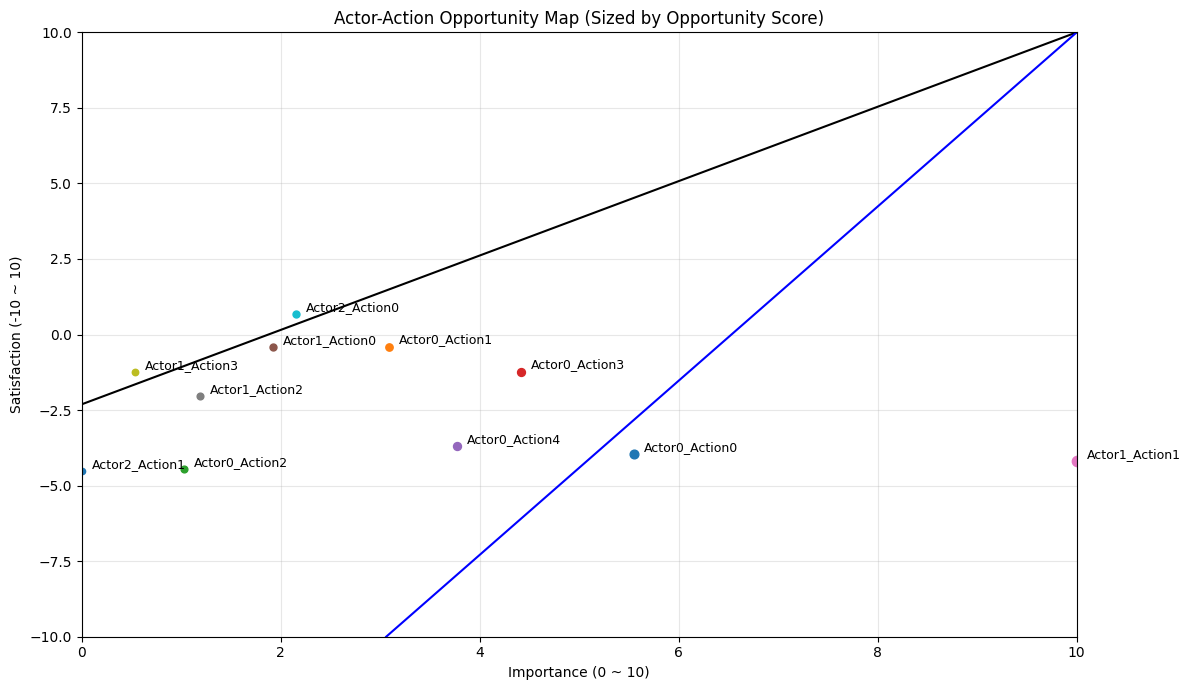

In [ ]:

# point 크기를 opportunity_score로 반영
aa_summary2 = (
    sents_df.groupby('actor_action')
      .agg(
          satisfaction=('satisfaction', 'mean'),
          importance=('importance', 'mean'),
          opportunity=('opportunity_score', 'mean')
      )
      .reset_index()
)

plt.figure(figsize=(12, 7))

for _, row in aa_summary2.iterrows():
    x = row['importance']
    y = row['satisfaction']
    size = 20 + row['opportunity'] * 5   # 기회영역 클수록 점 크게
    label = row['actor_action']

    plt.scatter(x, y, s=size)
    plt.text(x + 0.1, y + 0.1, label, fontsize=9)

# -------------------------------
# 여기부터 선 2개 (예전 그래프 형태 그대로)
# -------------------------------
mean_satis = aa_summary2['satisfaction'].mean()
mean_imp   = aa_summary2['importance'].mean()

# 1) 검은 선: (0, 평균 만족도) → (10, 10)
plt.plot([0, 10], [mean_satis, 10], 'k-')

# 2) 파란 선: (평균 중요도, -10) → (10, 10)
plt.plot([mean_imp, 10], [-10, 10], color='blue', linestyle='-')

plt.xlim(0, 10)
plt.ylim(-10, 10)
plt.xlabel('Importance (0 ~ 10)')
plt.ylabel('Satisfaction (-10 ~ 10)')
plt.title('Actor-Action Opportunity Map (Sized by Opportunity Score)')
plt.savefig('/content/drive/My Drive/Colab Notebooks/opportunity_map.png',
            dpi=300, bbox_inches='tight')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
X_clean = np.load('/content/drive/MyDrive/Colab Notebooks/클러스터링_임베딩.npy')

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

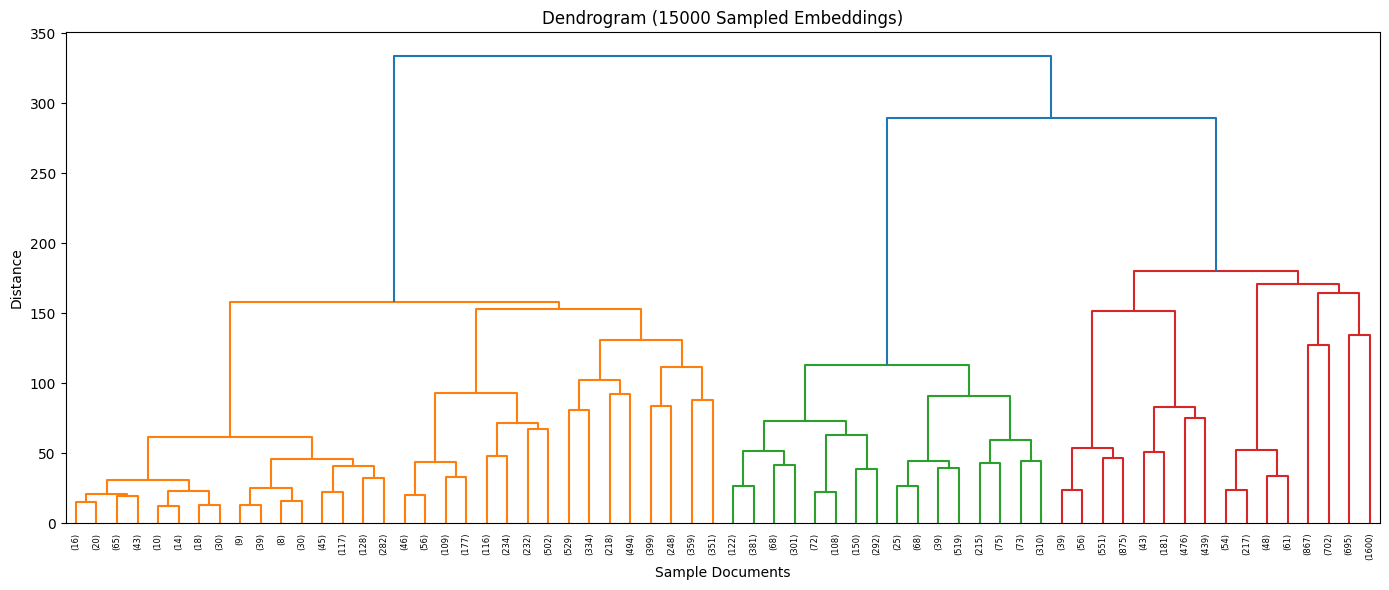

In [ ]:
N = X_clean.shape[0]
max_samples = 15000

if N > max_samples:
    idx = np.random.choice(N, size=max_samples, replace=False)
    X_sample = X_clean[idx]
else:
    X_sample = X_clean

# -------------------------------------------
# 계층 클러스터링
# -------------------------------------------
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="level",
    p=5,
)

plt.title("Dendrogram (15000 Sampled Embeddings)")
plt.xlabel("Sample Documents")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
df2 = df[['articles','cluster_v2','action_cluster','satisfaction','importance','opportunity_score']].copy()

In [ ]:
df2[(df2['cluster_v2']== 0 ) & (df2['action_cluster']== 3)]['articles'][0]


KeyError: 0

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import ast

# 1) 클러스터별 텍스트 준비 (tokens를 공백으로 join해서 사용)
cluster_id = 0
tmp = df[df['cluster_v2'] == cluster_id]

# Convert string representation of list to actual list, then join
texts = tmp['re_article_words'].apply(ast.literal_eval).apply(lambda x: ' '.join(x)).tolist()

# 2) TF-IDF 계산
vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

# 3) 전체 문서의 평균 TF-IDF 점수로 상위 단어 보기

mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
idx = mean_tfidf.argsort()[::-1]  # 내림차순
top_n = 30

top_terms = [(feature_names[i], round(mean_tfidf[i],5)) for i in idx[:top_n]]
top_terms

[('생각', np.float64(0.05054)),
 ('사람', np.float64(0.04694)),
 ('치료', np.float64(0.03472)),
 ('시간', np.float64(0.03305)),
 ('집중', np.float64(0.03284)),
 ('증상', np.float64(0.0304)),
 ('성인', np.float64(0.02969)),
 ('문제', np.float64(0.02689)),
 ('영상', np.float64(0.02609)),
 ('장애', np.float64(0.02474)),
 ('감사', np.float64(0.02466)),
 ('마음', np.float64(0.02448)),
 ('공부', np.float64(0.0242)),
 ('집중력', np.float64(0.02392)),
 ('운동', np.float64(0.02361)),
 ('시작', np.float64(0.0232)),
 ('수면', np.float64(0.02286)),
 ('정도', np.float64(0.02274)),
 ('검사', np.float64(0.02249)),
 ('번아웃', np.float64(0.02043)),
 ('아이', np.float64(0.02008)),
 ('병원', np.float64(0.02002)),
 ('방법', np.float64(0.02)),
 ('자신', np.float64(0.01991)),
 ('행동', np.float64(0.01926)),
 ('기력', np.float64(0.01922)),
 ('일상', np.float64(0.01884)),
 ('필요', np.float64(0.01871)),
 ('정신', np.float64(0.01825)),
 ('복용', np.float64(0.01825))]

In [ ]:
top_term_ = pd.DataFrame(top_terms, columns= ['word','score'])

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Nanum Gothic 폰트 설치
#!apt-get update -qq
#!apt-get install fonts-nanum -qq

# 폰트 캐시 재생성
fm.rebuild()

# 런타임 재시작 안내 (필요한 경우)
print("--------------------------------------------------------------------------")
print("한글 폰트 설치가 완료되었습니다. 런타임 재시작이 필요합니다. (런타임 > 런타임 다시 시작)")
print("--------------------------------------------------------------------------")

^C


AttributeError: module 'matplotlib.font_manager' has no attribute 'rebuild'

In [ ]:
# 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("Matplotlib 폰트 설정이 완료되었습니다. 런타임 재시작 후 모든 셀을 다시 실행한 뒤, 히트맵을 다시 그려보세요.")

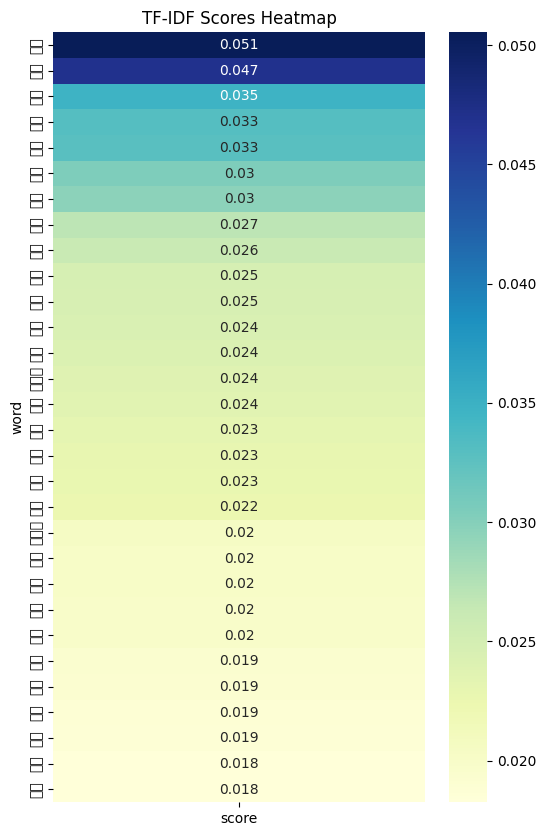

In [ ]:
import seaborn as sns

plt.figure(figsize=(6, 10))
sns.heatmap(
    top_term_.set_index("word"),
    annot=True,
    cmap="YlGnBu"
)

plt.title("TF-IDF Scores Heatmap")
plt.show()